# Projet IA — Exploratory Data Analysis

## Introduction

Ce notebook a pour objectif d'analyser les données RH d'une entreprise afin de comprendre et prédire l'attrition des employés (turnover). Les données proviennent de plusieurs sources fusionnées : données générales, enquêtes employés, enquêtes managers et horaires de présence.

---

## 1. Importation des bibliothèques

On commence par importer les bibliothèques essentielles à l'analyse :
- **NumPy** et **Pandas** pour la manipulation des données
- **Matplotlib** et **Seaborn** pour la visualisation
- **warnings** et **os** pour la gestion de l'environnement d'exécution

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

## 2. Configuration de l'environnement

Cette cellule configure les paramètres d'affichage globaux pour rendre les visualisations et les sorties plus lisibles tout au long du notebook :
- Taille des graphiques par défaut
- Style visuel de Seaborn
- Précision d'affichage des nombres
- Suppression des avertissements non critiques

In [2]:
# Configuring display settings
plt.rcParams['figure.figsize'] = (12, 9)
sns.set()
sns.set_context('talk')
np.set_printoptions(threshold=20, precision=2, suppress=True)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings("ignore", category=FutureWarning)

## 3. Chargement et fusion des données

Les données sont réparties dans plusieurs fichiers CSV distincts. On les charge ici et on les fusionne en un seul DataFrame `employee_data` via l'identifiant commun `EmployeeID`.

Les sources de données sont :
- `general_data.csv` — informations générales sur les employés (âge, département, salaire, etc.)
- `employee_survey_data.csv` — résultats de l'enquête de satisfaction des employés
- `manager_survey_data.csv` — évaluations réalisées par les managers

> **Note :** Les fichiers d'horaires (`in_time` et `out_time`) sont chargés mais non fusionnés pour l'instant (lignes commentées).

In [3]:
# Correcting file paths to match the actual directory structure
data_dir = 'data'
employee_survey = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'employee_survey_data.csv'))
general_data = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'general_data.csv'))
manager_survey = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'manager_survey_data.csv'))
in_time = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'in_out_time', 'in_time.csv'))
out_time = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'in_out_time' ,'out_time.csv'))

in_time.rename(columns={in_time.columns[0]: 'EmployeeID'}, inplace=True)
out_time.rename(columns={out_time.columns[0]: 'EmployeeID'}, inplace=True)

# Merging datasets
employee_data = pd.merge(general_data, employee_survey, on='EmployeeID', how='left')
employee_data = pd.merge(employee_data, manager_survey, on='EmployeeID', how='left')
#employee_data = pd.merge(employee_data, in_time, on='EmployeeID', how='left')
#employee_data = pd.merge(employee_data, out_time, on='EmployeeID', how='left')

# Displaying the first few rows of the merged dataset
employee_data.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,1,Healthcare Representative,Married,131160,1.00,Y,11,8,0,1.00,6,1,0,0,3.00,4.00,2.00,3,3
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,1,Research Scientist,Single,41890,0.00,Y,23,8,1,6.00,3,5,1,4,3.00,2.00,4.00,2,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,4,Sales Executive,Married,193280,1.00,Y,15,8,3,5.00,2,5,0,3,2.00,2.00,1.00,3,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,3,Human Resources,Married,83210,3.00,Y,11,8,3,13.00,5,8,7,5,4.00,4.00,3.00,2,3
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,1,Sales Executive,Single,23420,4.00,Y,12,8,2,9.00,2,6,0,4,4.00,1.00,3.00,3,3


## 4. Gestion des valeurs manquantes

Avant toute analyse, il est essentiel de détecter et traiter les valeurs manquantes pour éviter des biais ou des erreurs dans les modèles.

**Stratégie d'imputation :**
- **Variables numériques** → remplacement par la **médiane** (robuste aux valeurs aberrantes)
- **Variables catégorielles** → remplacement par le **mode** (valeur la plus fréquente)

La visualisation via `missingno` permet d'identifier rapidement les colonnes concernées avant l'imputation.

C:\Users\loris\AppData\Local\Temp\ipykernel_22144\3665548754.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = employee_data.select_dtypes(include=['object']).columns


Age                        0
Attrition                  0
BusinessTravel             0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
EmployeeCount              0
EmployeeID                 0
Gender                     0
JobLevel                   0
JobRole                    0
MaritalStatus              0
MonthlyIncome              0
NumCompaniesWorked         0
Over18                     0
PercentSalaryHike          0
StandardHours              0
StockOptionLevel           0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
EnvironmentSatisfaction    0
JobSatisfaction            0
WorkLifeBalance            0
JobInvolvement             0
PerformanceRating          0
dtype: int64

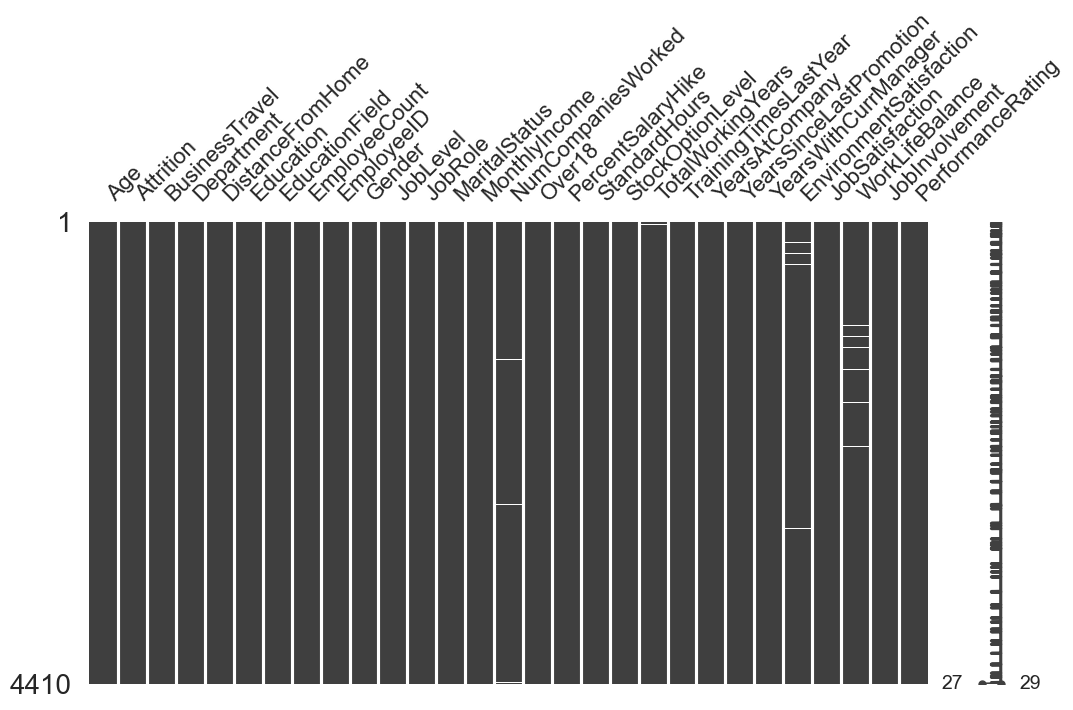

In [4]:
import missingno as msno

# Visualizing missing data
msno.matrix(employee_data[employee_data.columns], figsize=(12, 6))

# Impute missing values
# For numerical columns, use median imputation
numerical_columns = employee_data.select_dtypes(include=['float64', 'int64']).columns
employee_data[numerical_columns] = employee_data[numerical_columns].fillna(employee_data[numerical_columns].median())

# For categorical columns, use mode imputation
employee_data['Over18'] = employee_data['Over18'].fillna('N')
categorical_columns = employee_data.select_dtypes(include=['object']).columns
employee_data[categorical_columns] = employee_data[categorical_columns].fillna(employee_data[categorical_columns].mode().iloc[0])

# Verify that there are no more missing values
employee_data.isnull().sum()

## 5. Analyse univariée des variables

Cette étape consiste à examiner chaque variable individuellement pour comprendre sa distribution.

- **Variables numériques** : si la variable prend moins de 10 valeurs distinctes, on utilise un `countplot` (variable discrète) ; sinon, un histogramme avec courbe de densité (KDE).
- **Variables catégorielles** : affichage des fréquences par modalité avec un `countplot`.

Cette exploration permet de détecter des déséquilibres de classes, des valeurs aberrantes, ou des distributions particulières à prendre en compte dans la modélisation.

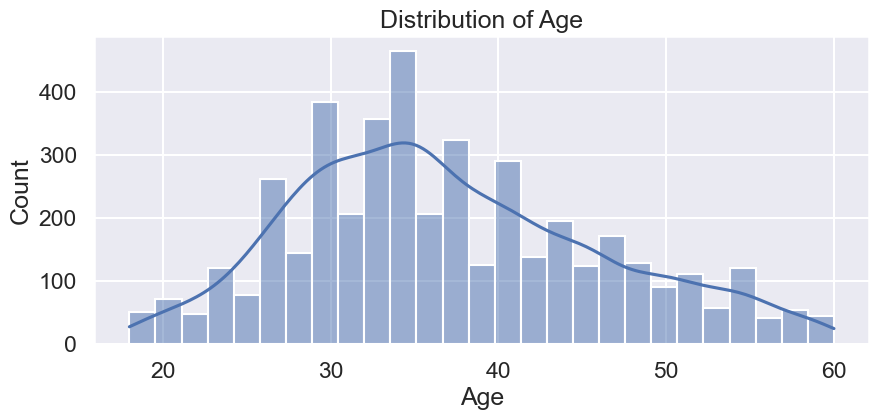

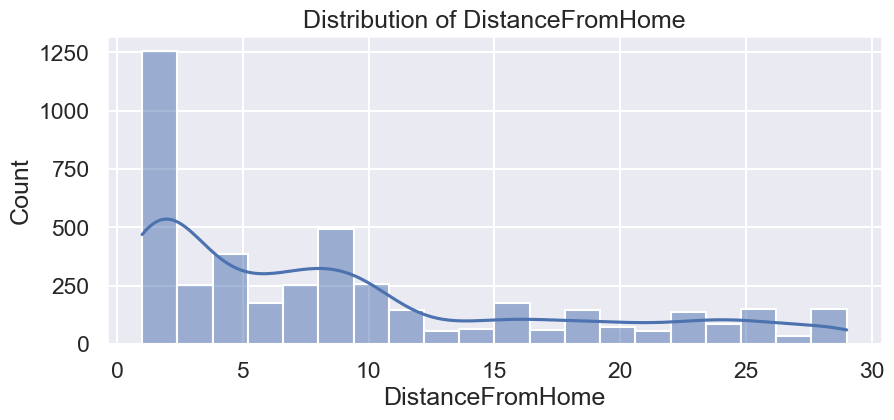

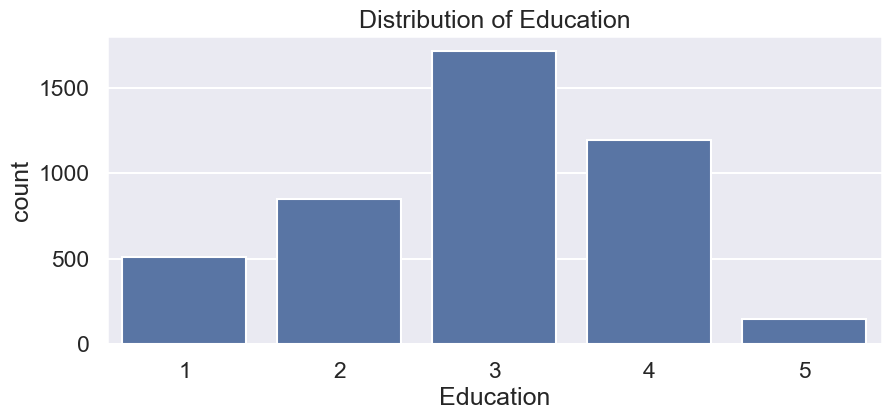

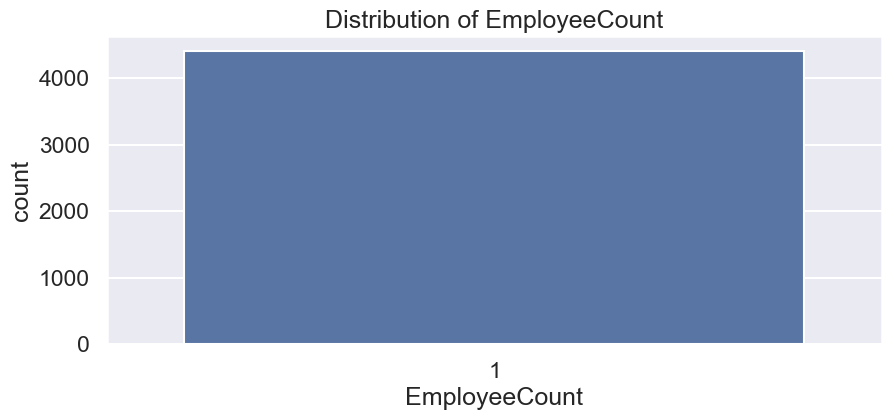

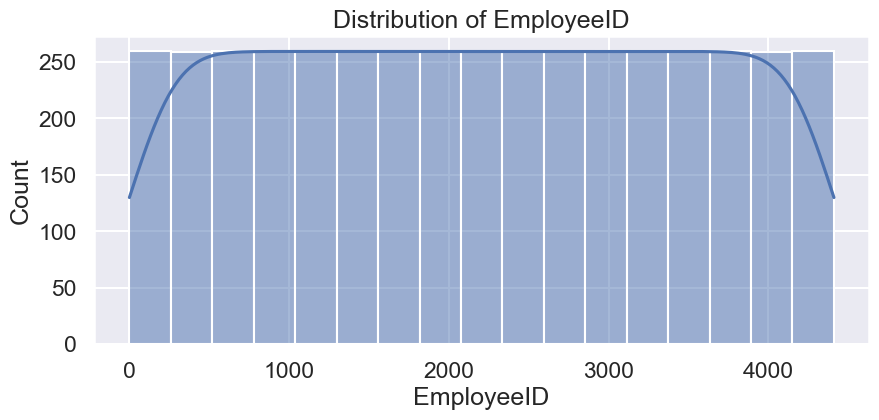

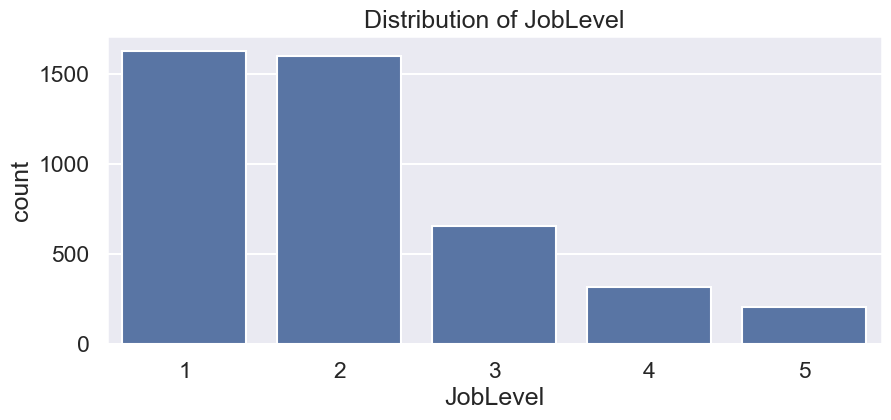

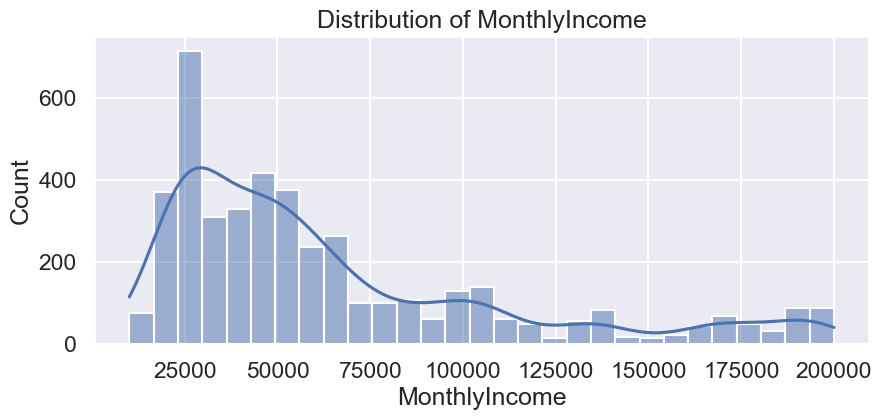

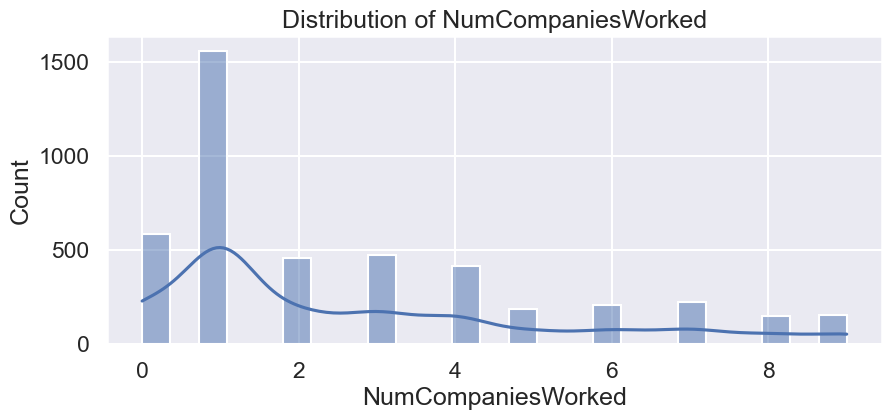

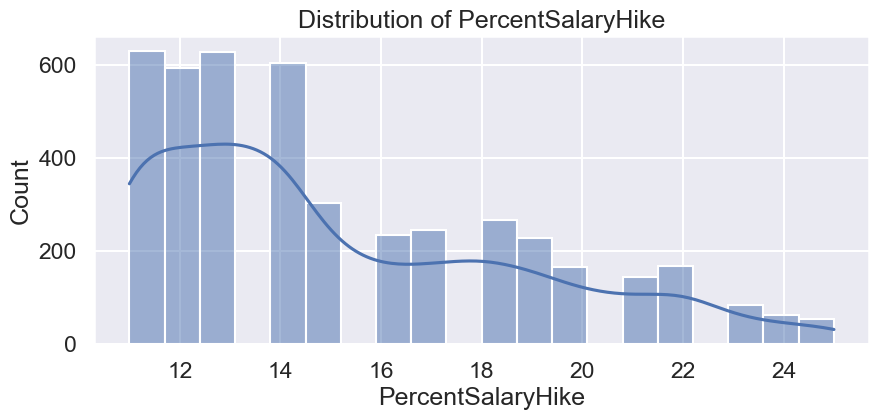

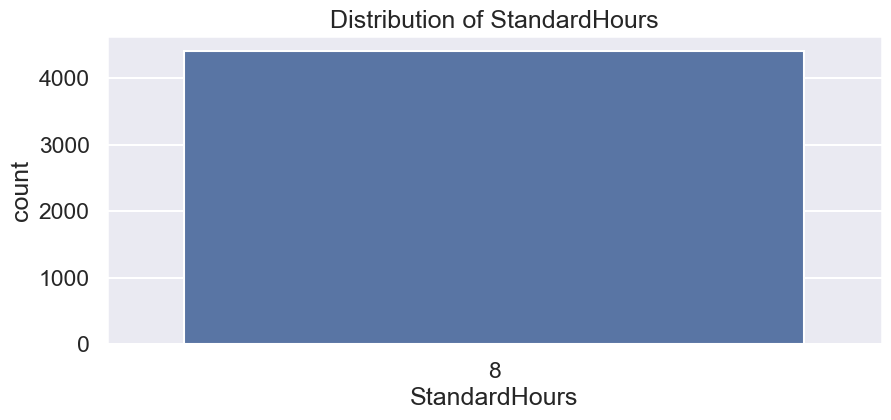

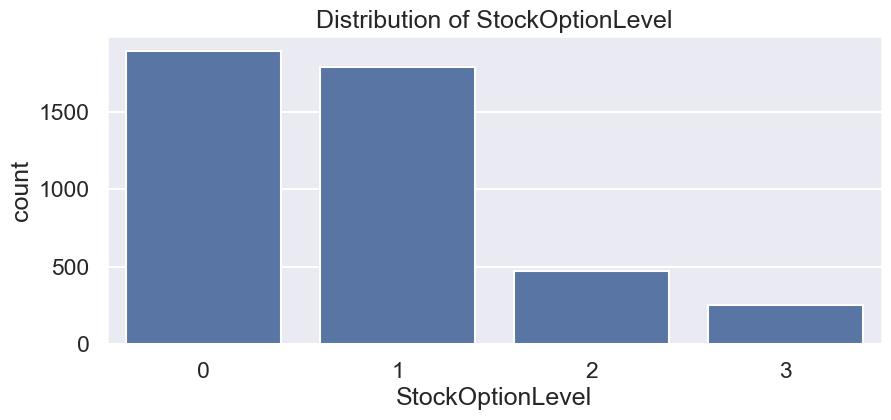

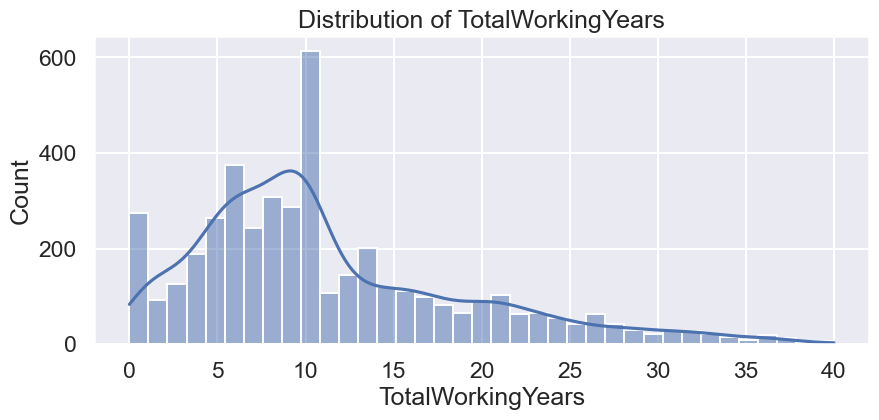

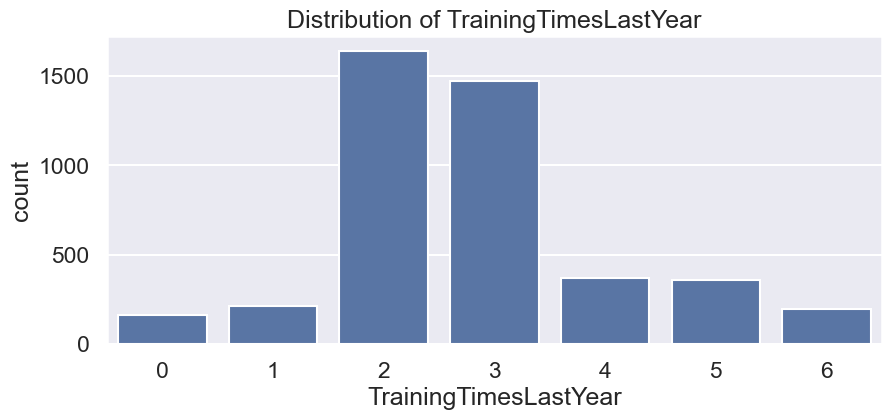

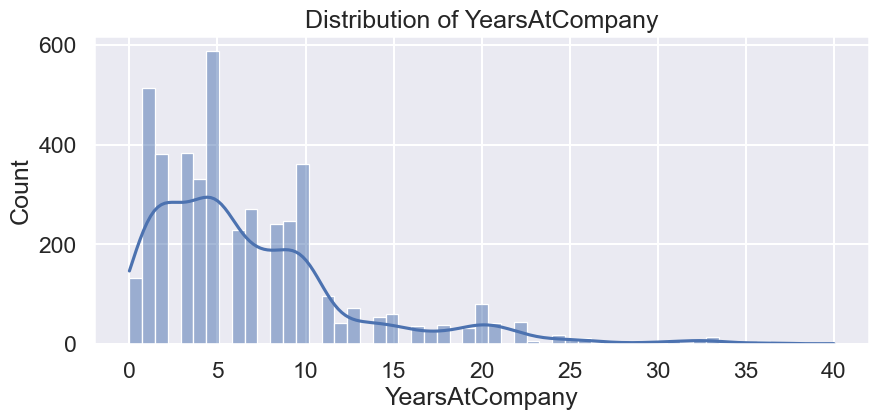

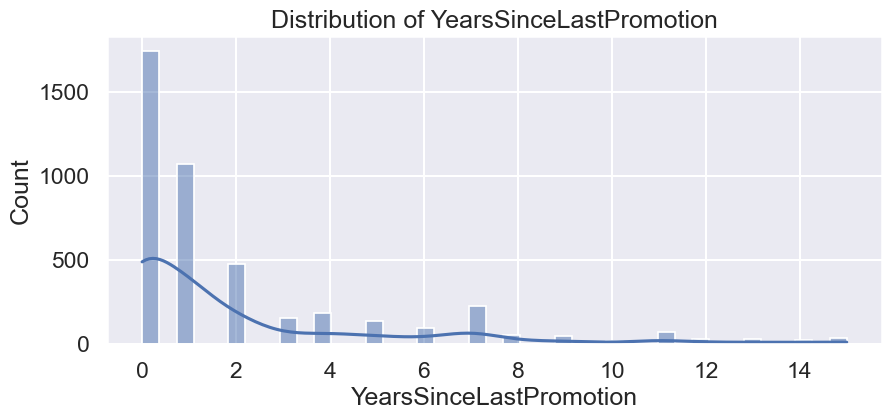

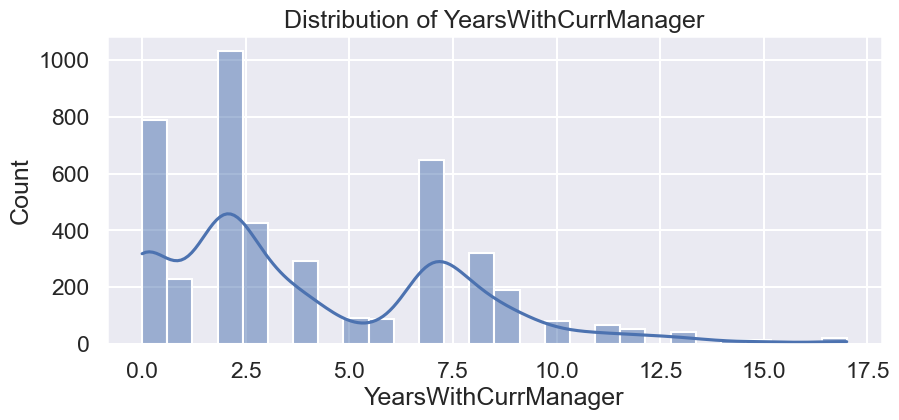

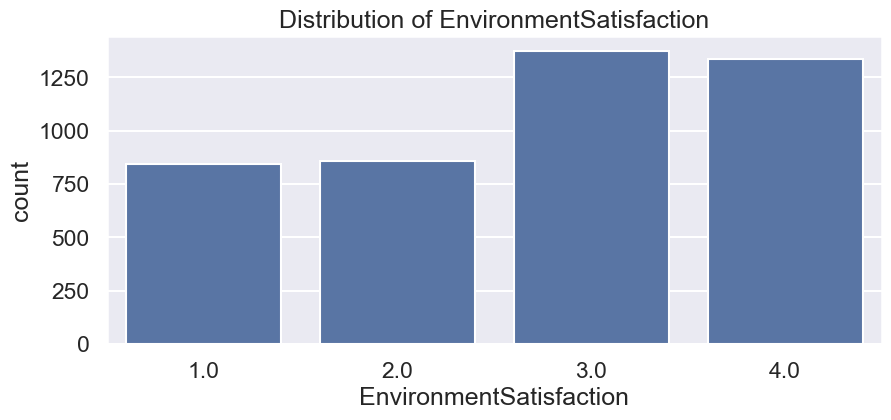

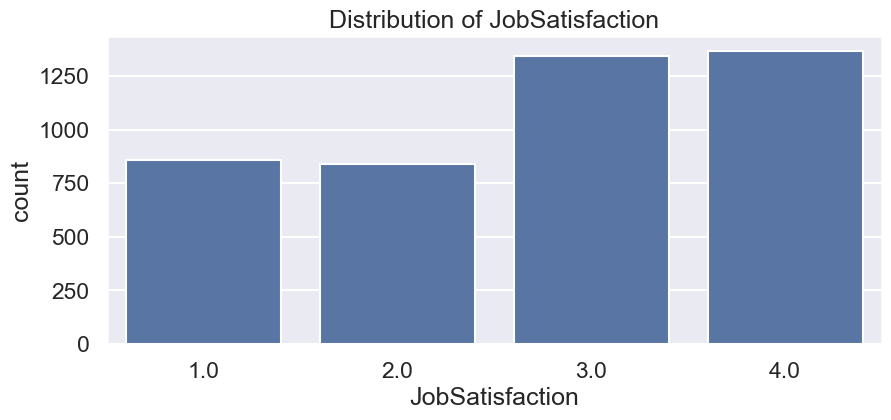

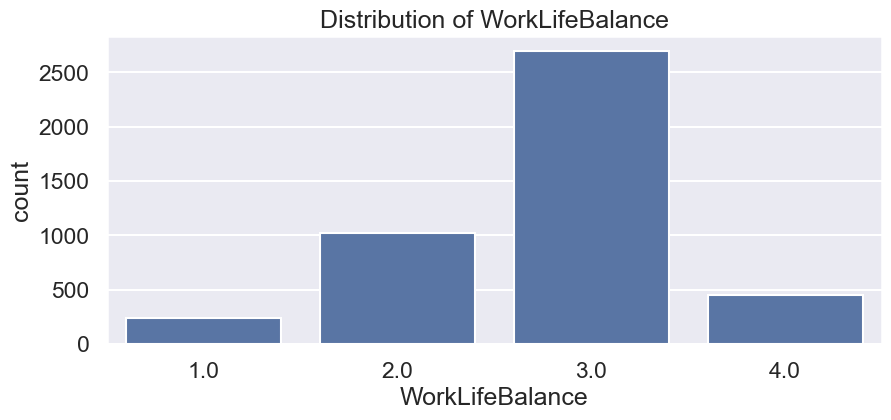

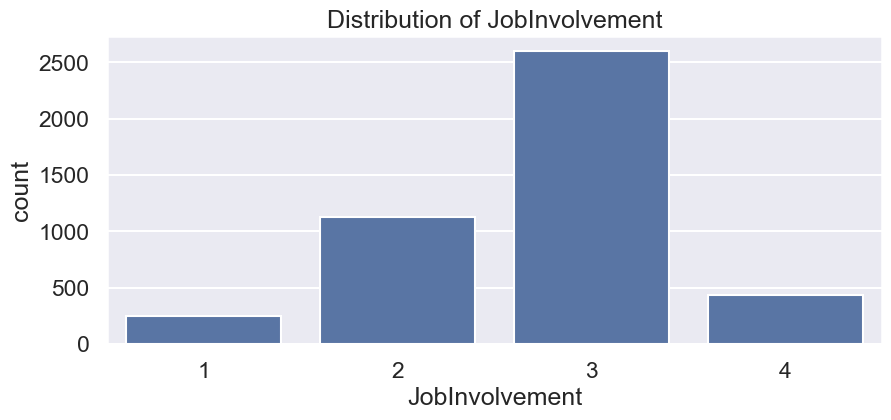

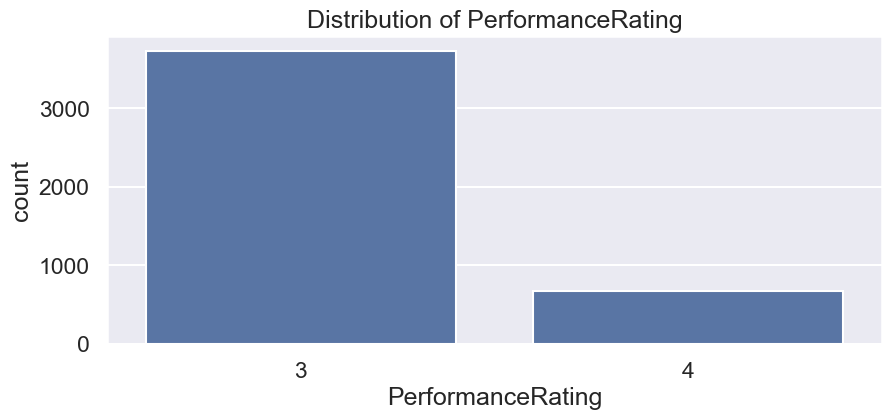

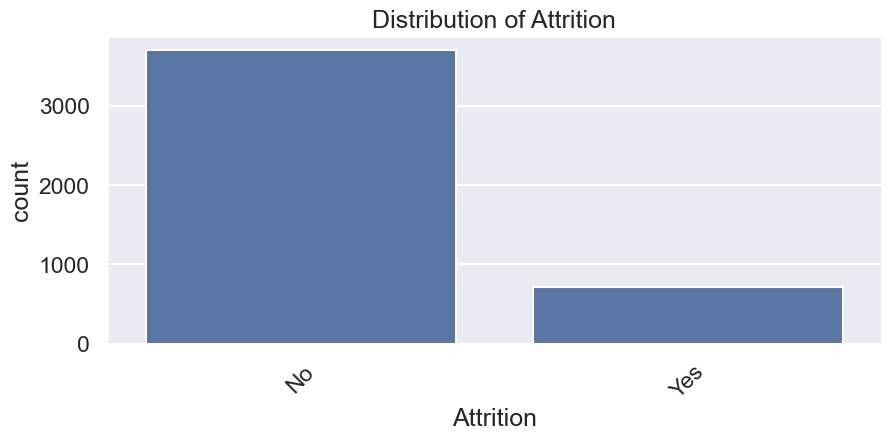

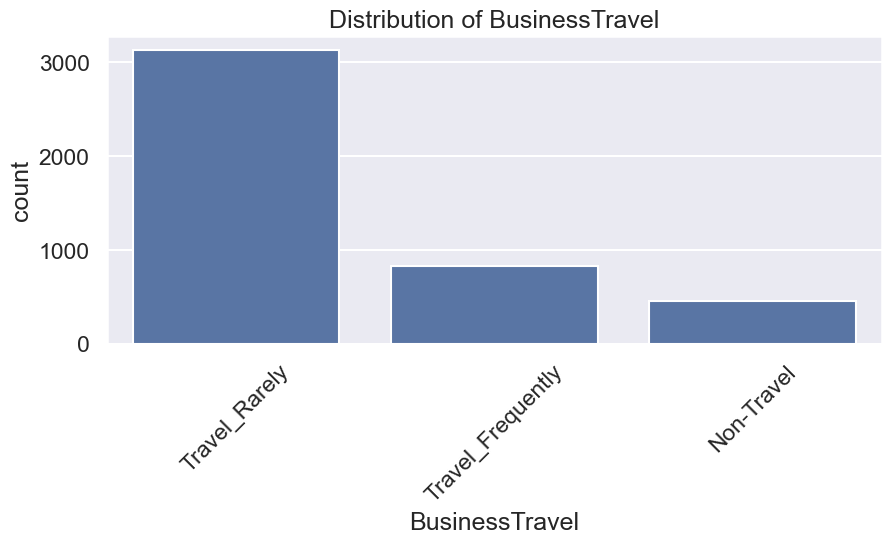

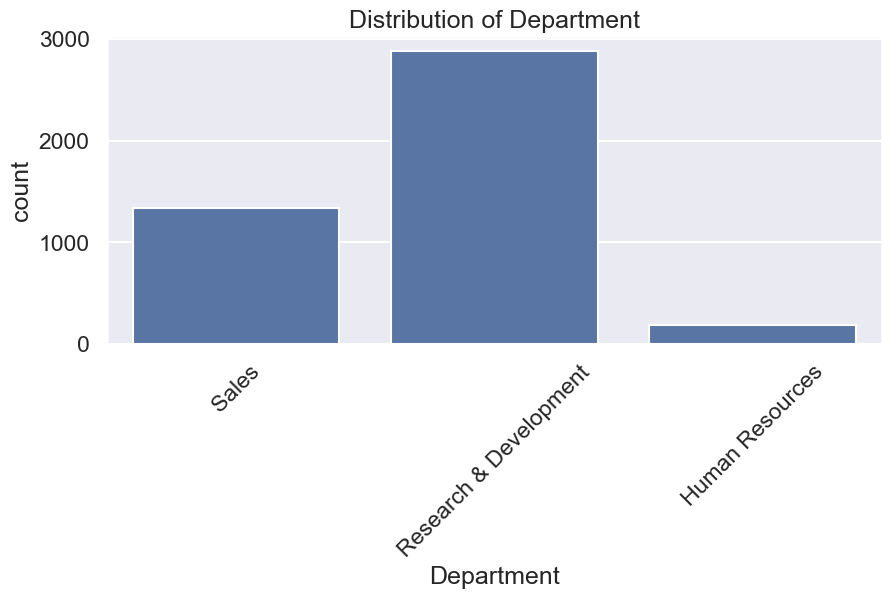

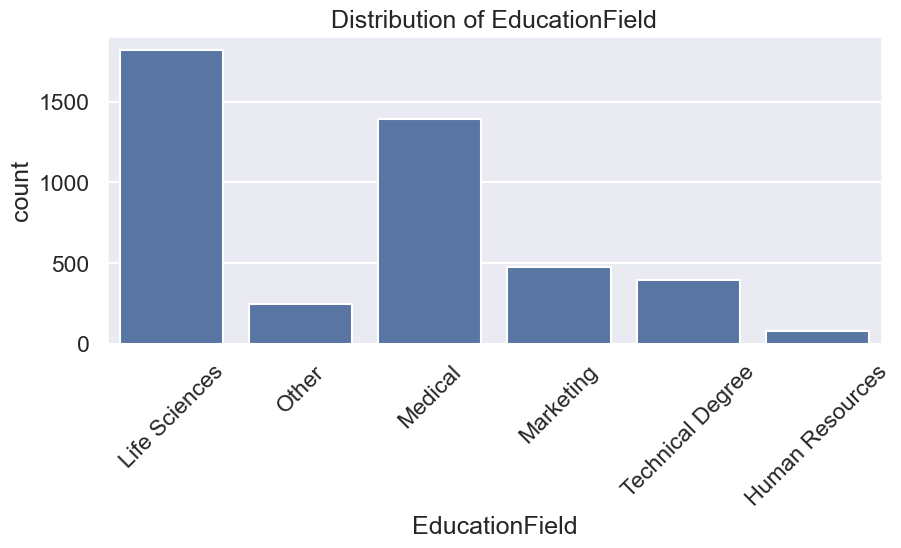

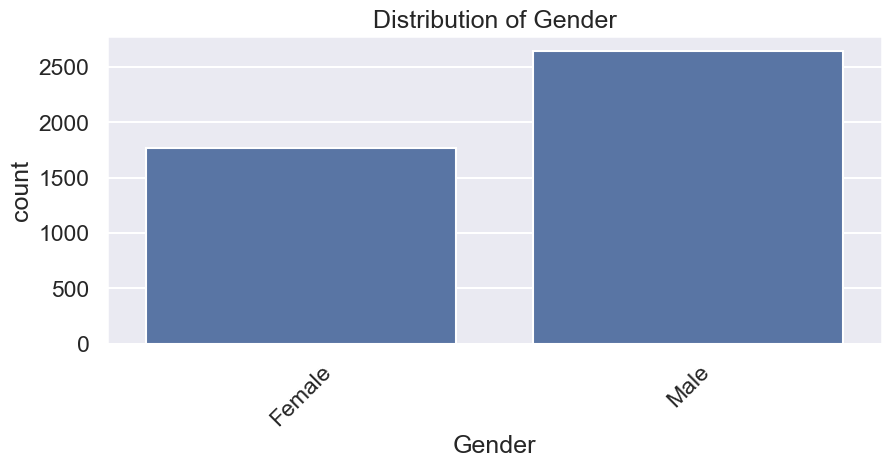

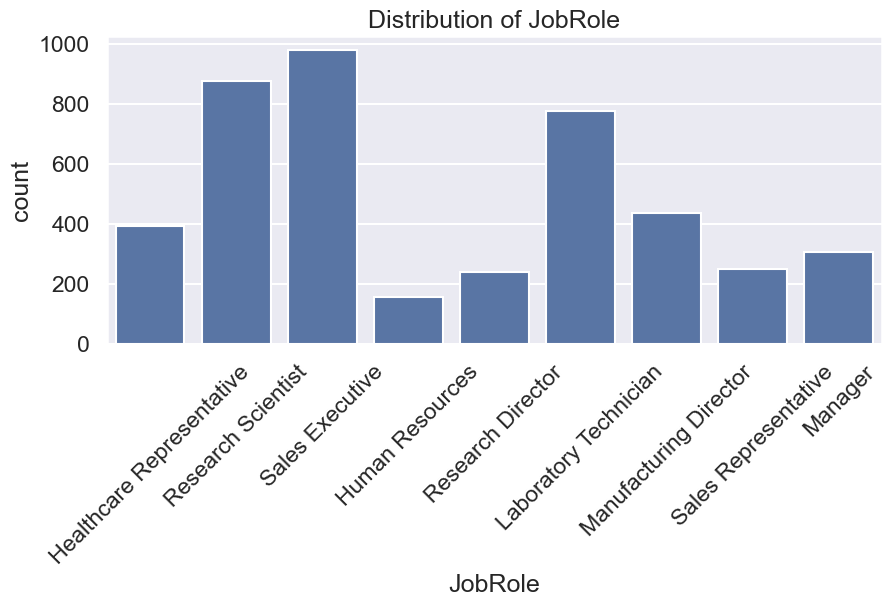

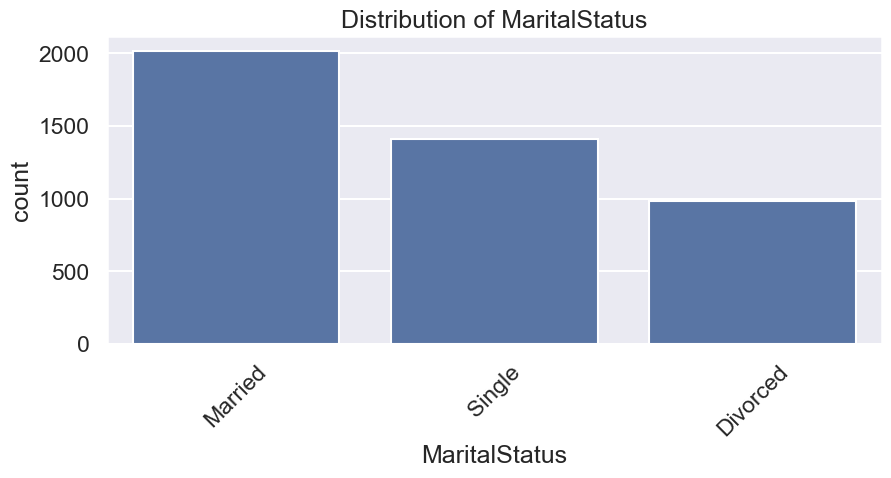

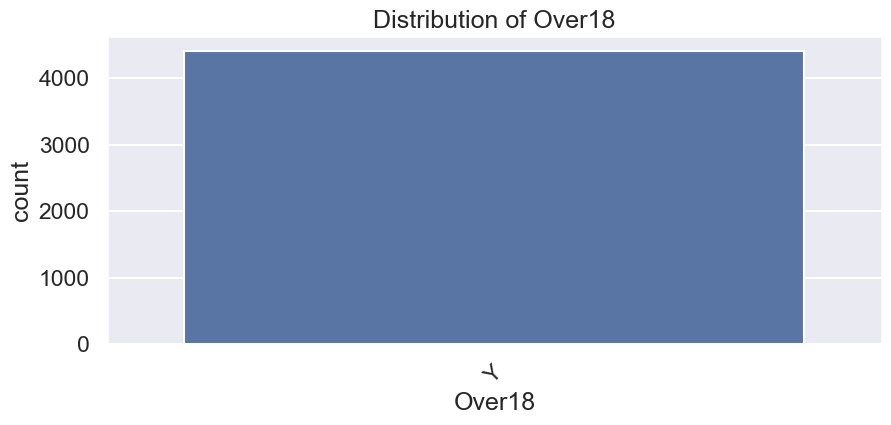

In [5]:
# Univariate analysis for numerical features
for column in numerical_columns:
    plt.figure(figsize=(10, 4))
    if(employee_data[column].nunique() < 10):
        sns.countplot(x=employee_data[column])
    else:
        sns.histplot(employee_data[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

# Univariate analysis for categorical features
for column in categorical_columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=employee_data[column])
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=45)
    plt.show()

## 6. Feature engineering — Heures travaillées

Les fichiers `in_time` et `out_time` contiennent les horaires d'arrivée et de départ de chaque employé pour chaque jour de l'année 2015.

On calcule ici, pour chaque employé, les indicateurs suivants :
- **`avg_hours_worked`** — durée de travail quotidienne moyenne (en heures)
- **`avg_hours_worked`** permet de quantifier la charge de travail réelle et de l'intégrer au jeu de données principal.

**Traitement :**
- Conversion des colonnes de timestamps en objets `datetime`
- Calcul de la durée journalière pour chaque présence (NaN si absent ce jour-là)
- Moyenne par employé sur l'ensemble de l'année

> **Note :** Les jours où l'employé est absent sont exclus du calcul de la moyenne (on ne les compte pas comme 0 heure travaillée).


In [6]:
# Convert all date columns to datetime (excluding EmployeeID)
date_cols = [c for c in in_time.columns if c != 'EmployeeID']

in_time[date_cols] = in_time[date_cols].apply(pd.to_datetime, errors='coerce')
out_time[date_cols] = out_time[date_cols].apply(pd.to_datetime, errors='coerce')

# Compute daily work duration in hours (NaN if absent)
work_duration = out_time[date_cols] - in_time[date_cols]
work_duration_hours = work_duration.apply(lambda col: col.dt.total_seconds() / 3600)

# Compute average daily hours worked per employee
avg_hours = work_duration_hours.mean(axis=1)
hours_df = pd.DataFrame({
    'EmployeeID': in_time['EmployeeID'],
    'avg_hours_worked': avg_hours
})

# Merge into main dataset
employee_data = pd.merge(employee_data, hours_df, on='EmployeeID', how='left')

# Preview
employee_data[['EmployeeID', 'avg_hours_worked']].head(10)


,EmployeeID,avg_hours_worked
0,1,7.37
1,2,7.72
2,3,7.01
3,4,7.19
4,5,8.01
5,6,10.80
6,7,6.92
7,8,6.73
8,9,7.24
9,10,7.08


## 7. Analyse bivariée — Variables vs Attrition

L'analyse bivariée consiste à croiser chaque variable avec la variable cible `Attrition` pour identifier les facteurs les plus discriminants.

- **Variables numériques** : comparaison des distributions selon Attrition via des `boxplots`.
- **Variables catégorielles** : taux d'attrition par modalité, exprimé en pourcentage.
- **`avg_hours_worked`** : variable issue du feature engineering, intégrée à cette analyse.

Cette étape est centrale pour répondre à la question métier : *quels sont les facteurs ayant le plus d'influence sur le départ des employés ?*


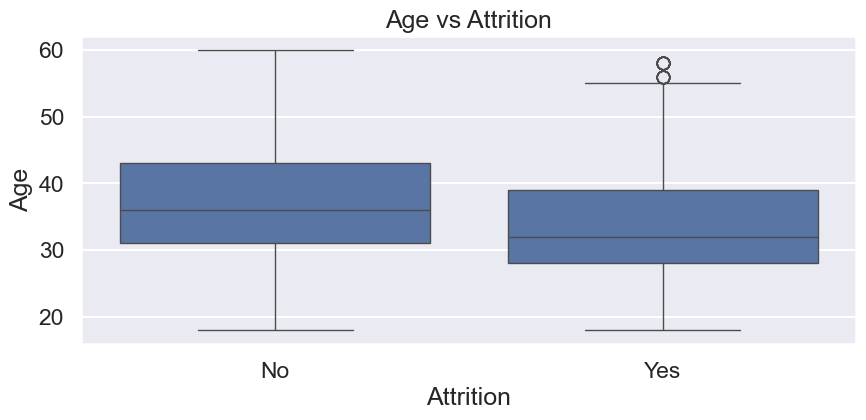

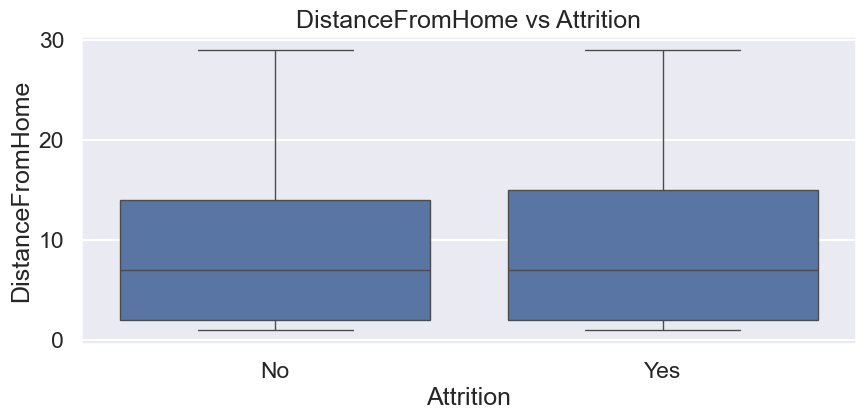

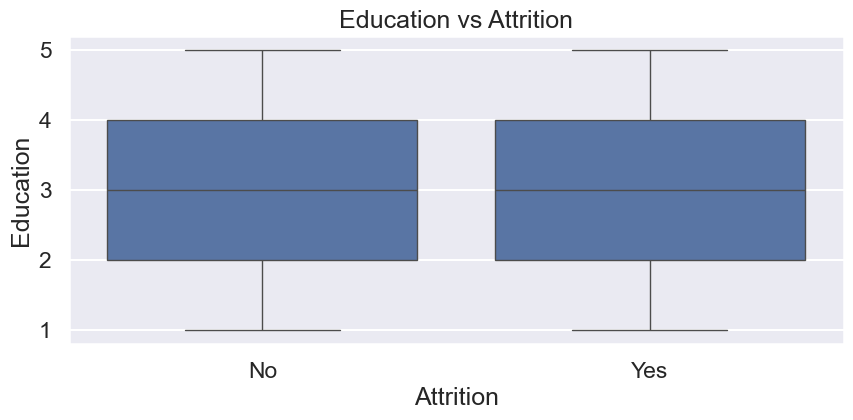

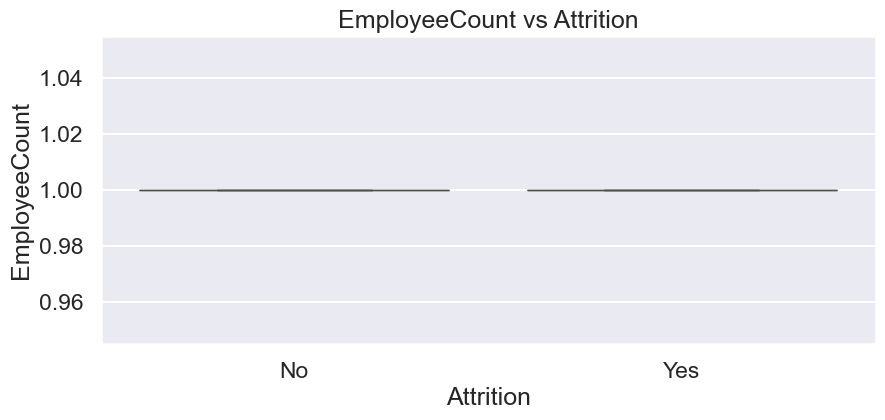

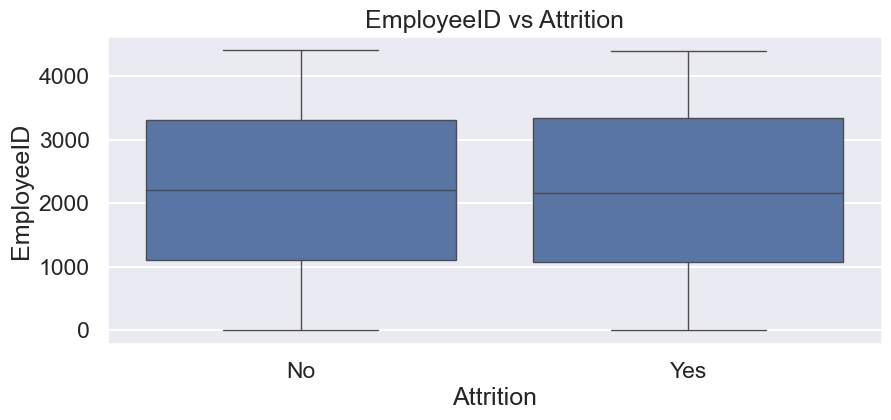

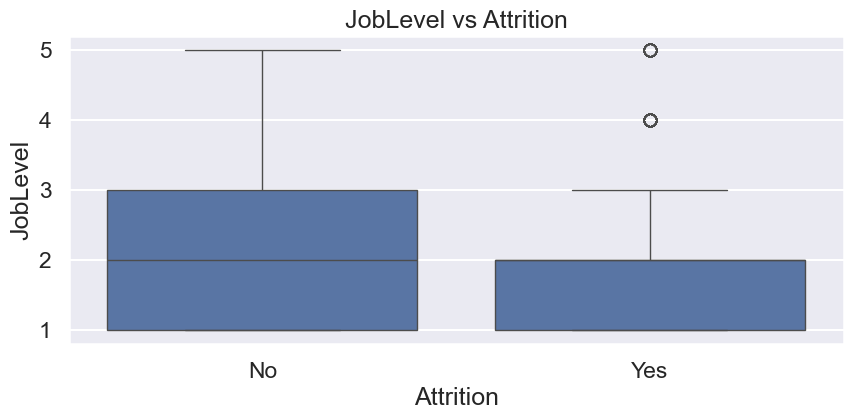

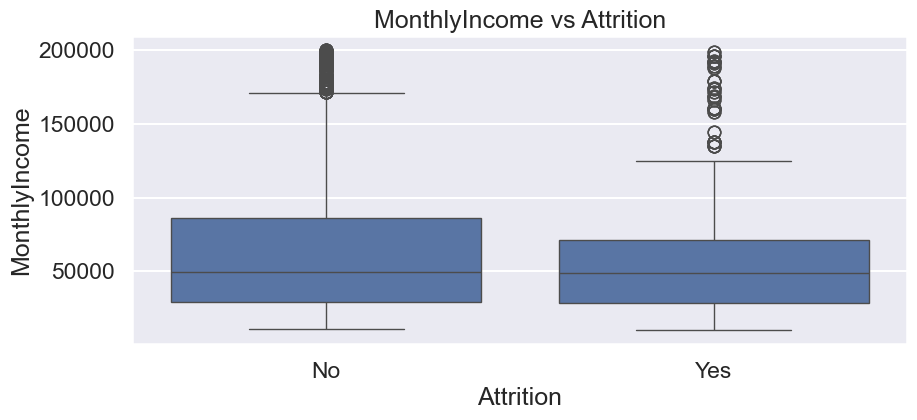

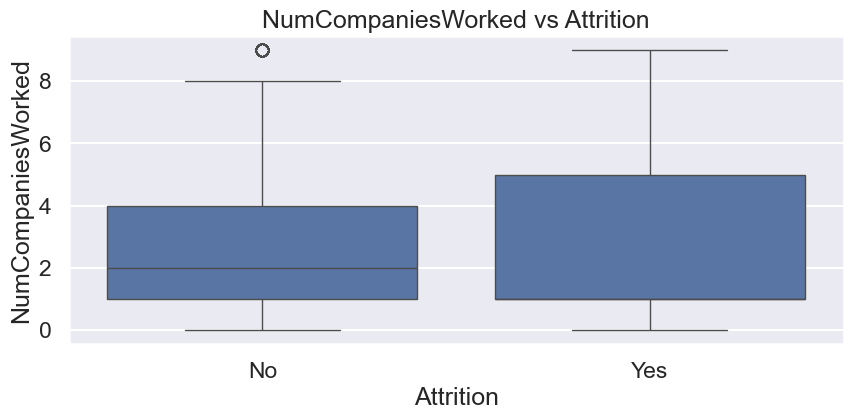

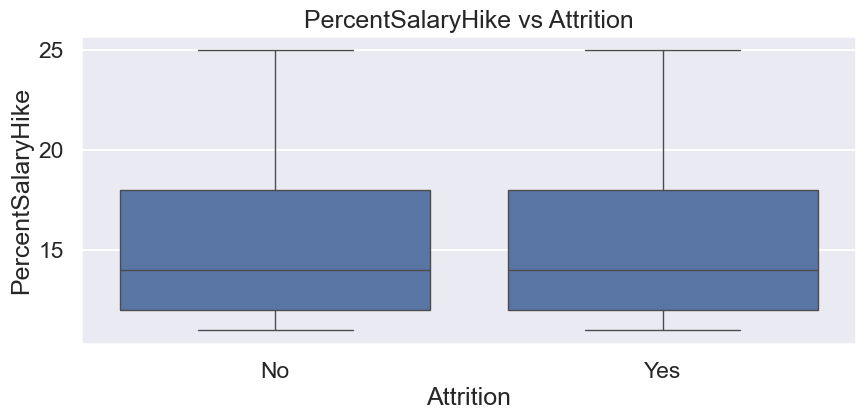

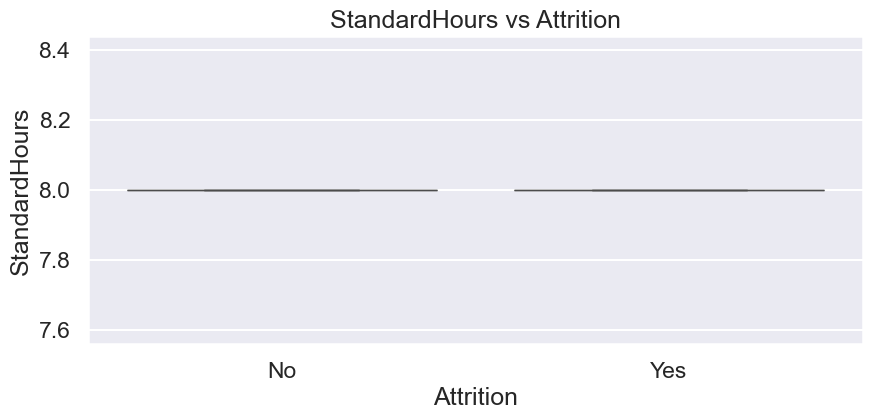

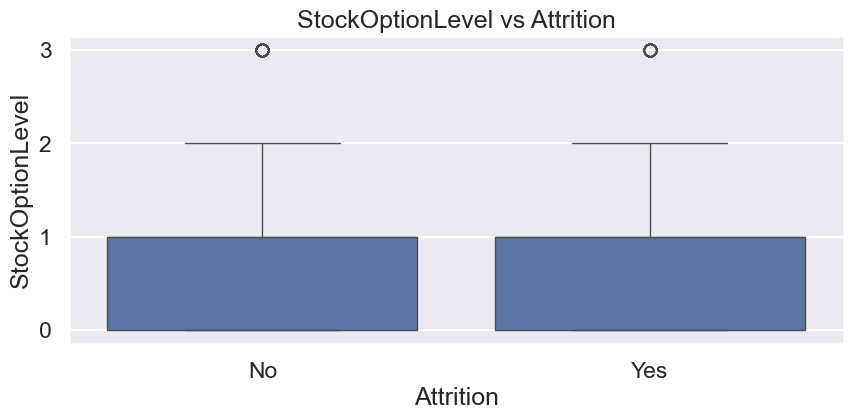

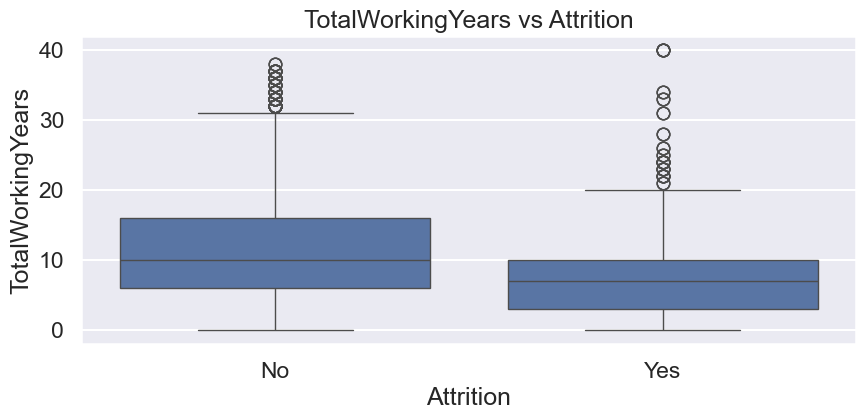

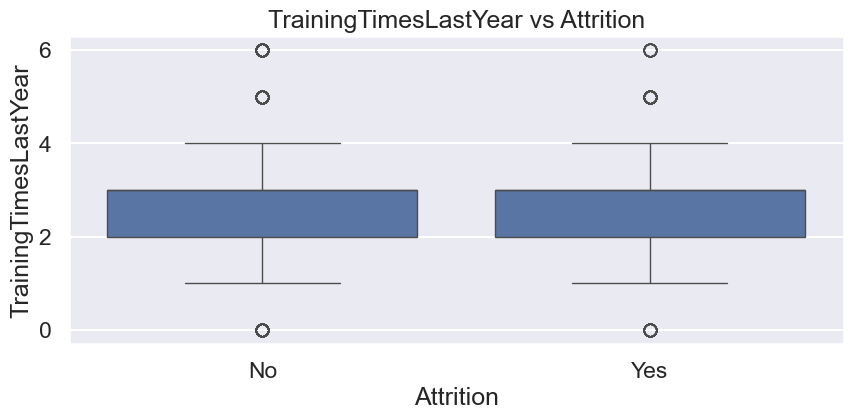

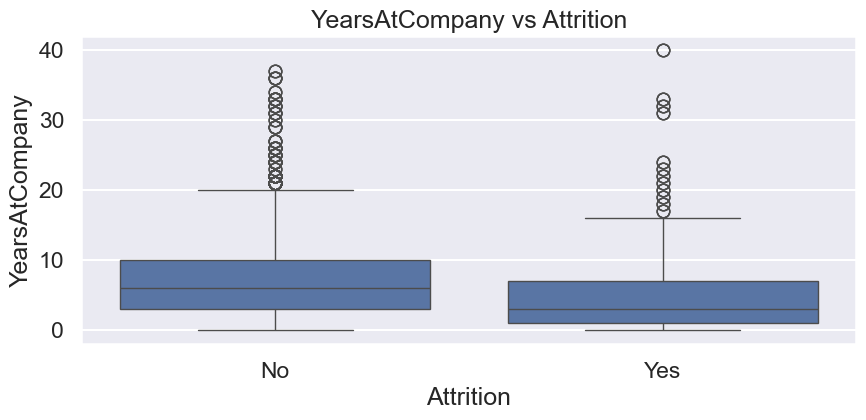

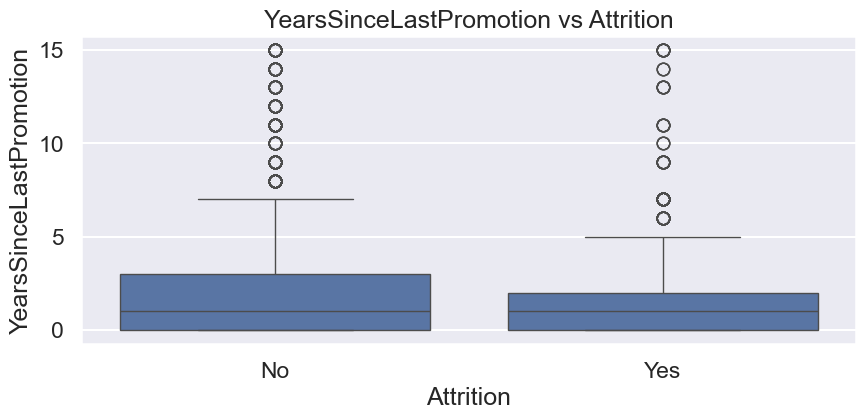

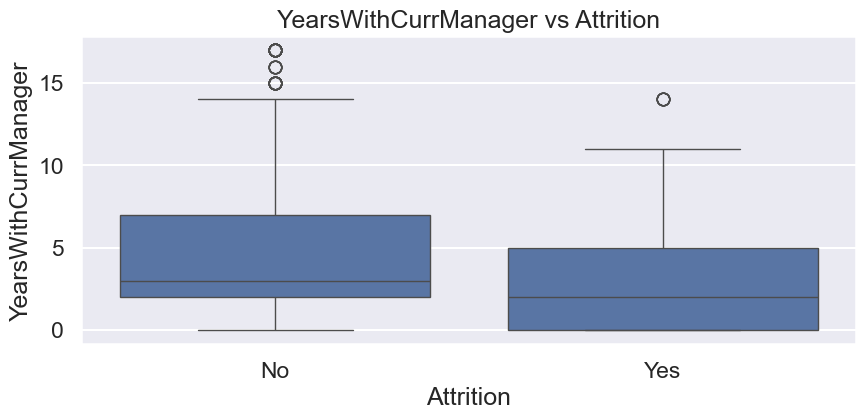

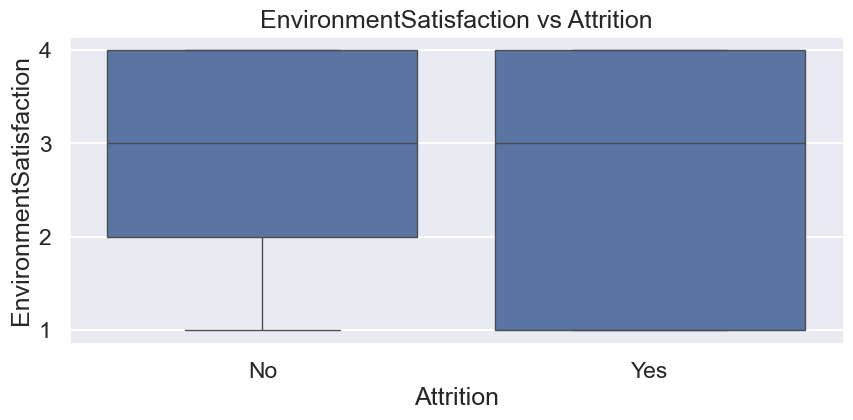

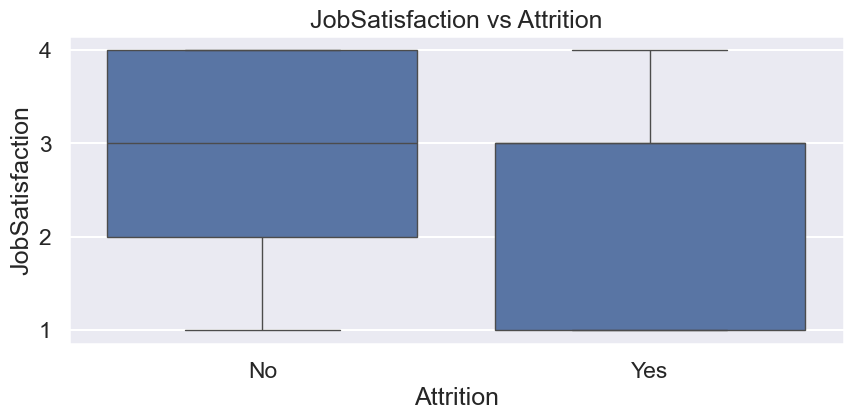

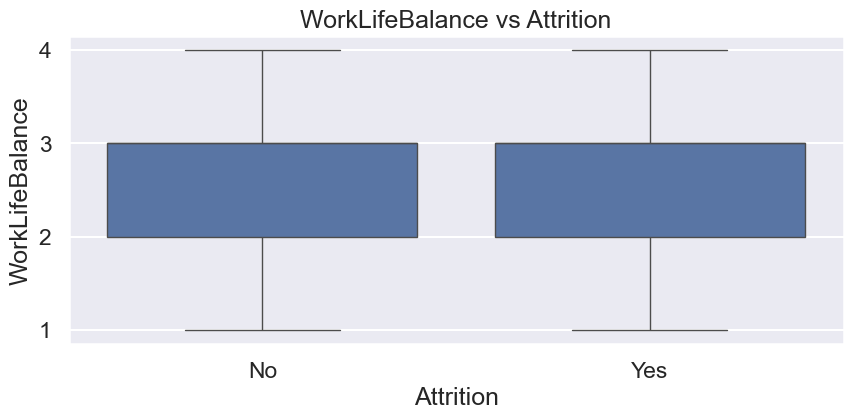

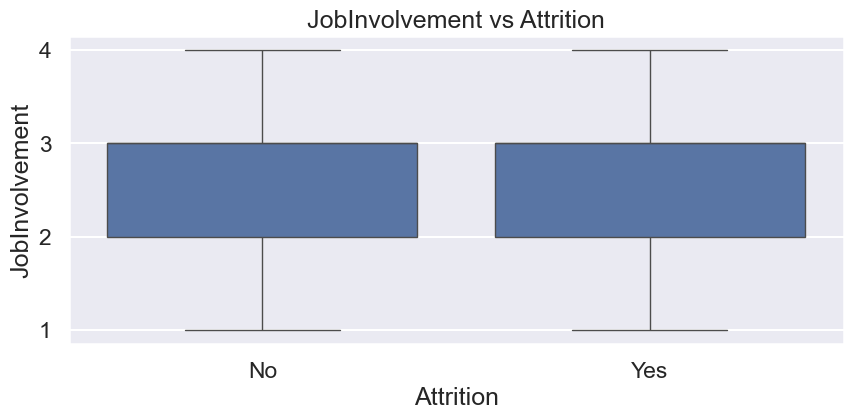

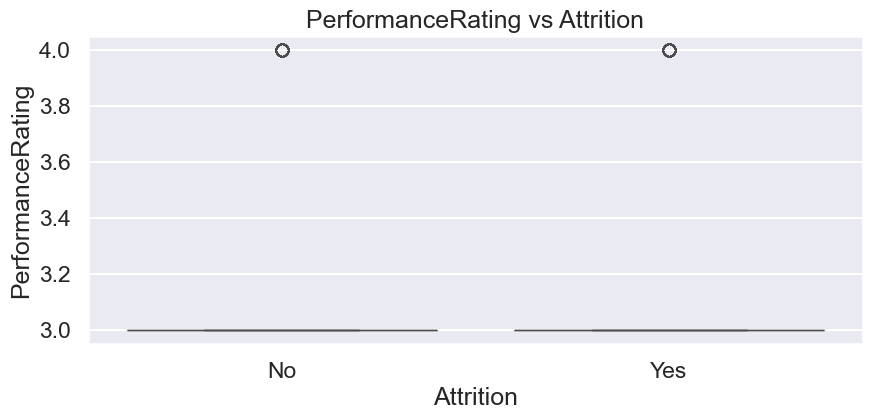

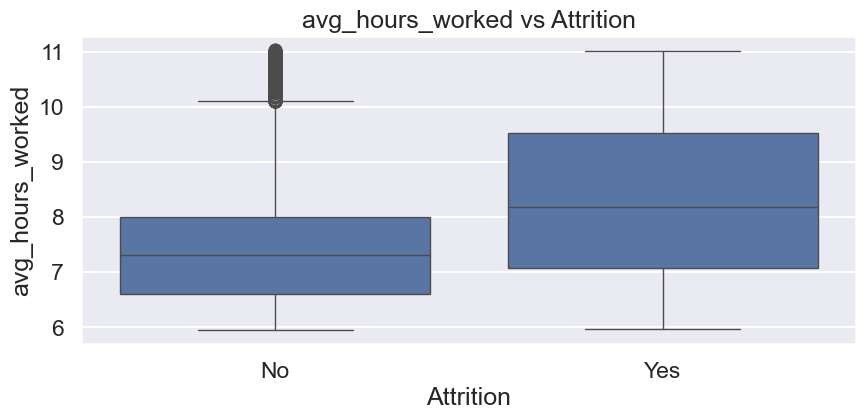

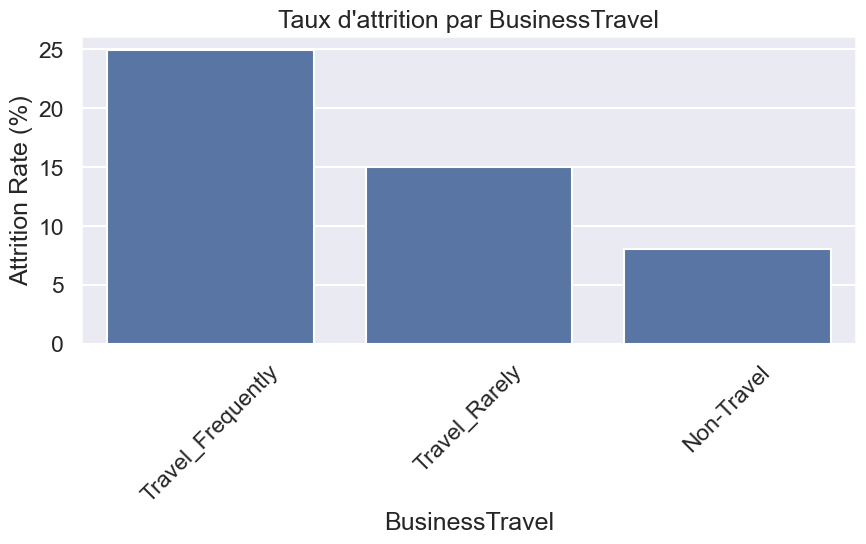

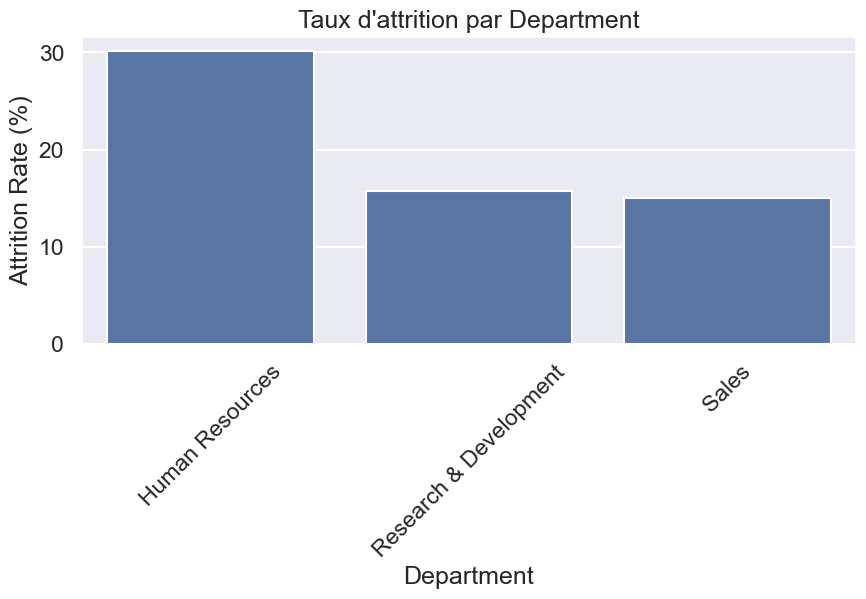

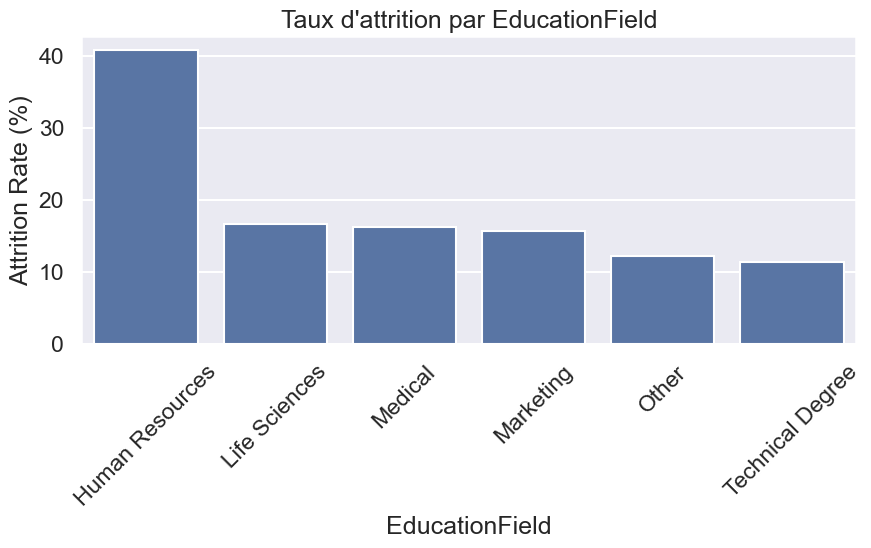

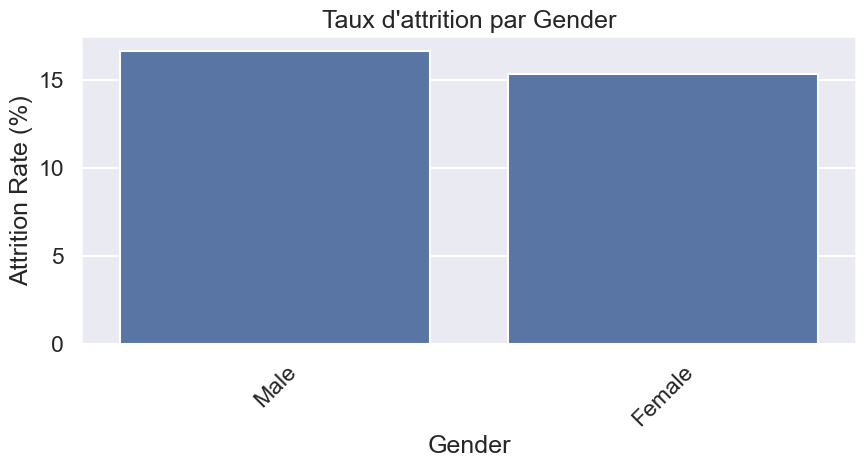

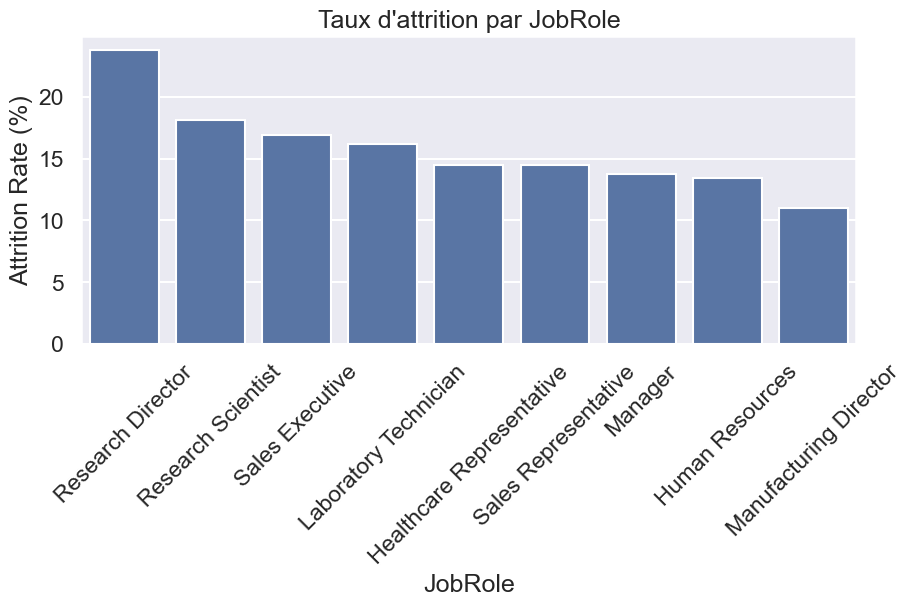

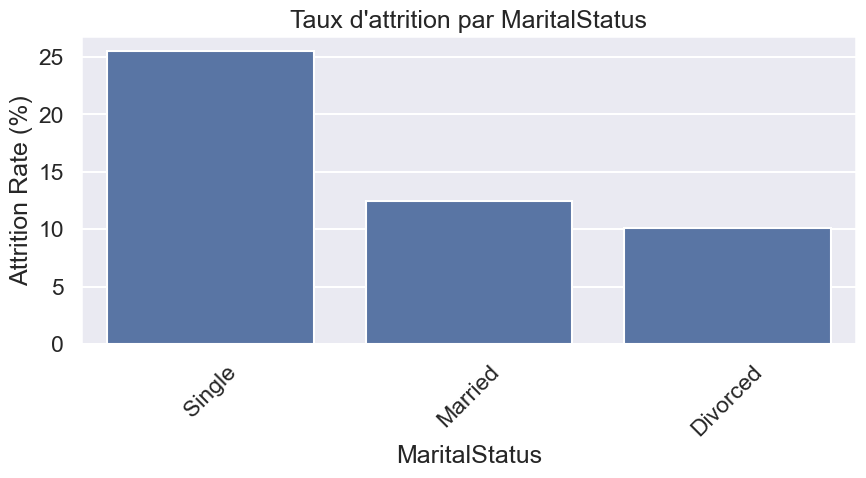

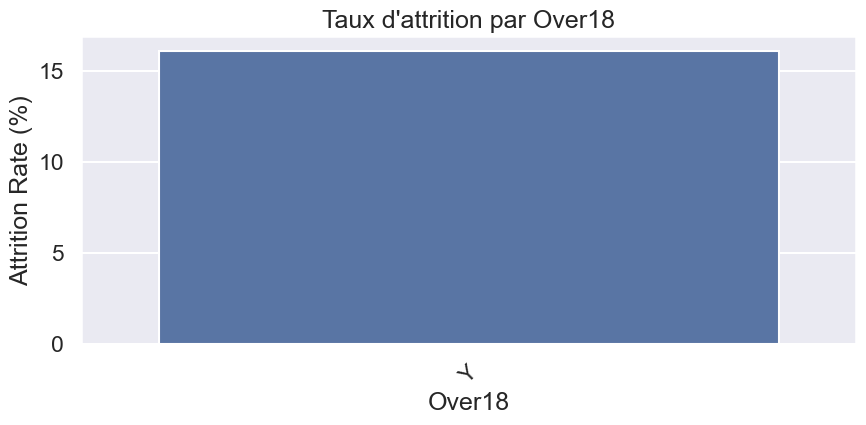

In [7]:
# Bivariate analysis — numerical variables vs Attrition
numerical_cols_bivar = list(numerical_columns) + ['avg_hours_worked']

for column in numerical_cols_bivar:
    if column in employee_data.columns:
        plt.figure(figsize=(10, 4))
        sns.boxplot(x='Attrition', y=column, data=employee_data)
        plt.title(f'{column} vs Attrition')
        plt.show()

# Bivariate analysis — categorical variables vs Attrition
for column in categorical_columns:
    if column == 'Attrition':
        continue
    attrition_rate = employee_data.groupby(column)['Attrition'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    attrition_rate.columns = [column, 'Attrition Rate (%)']
    attrition_rate = attrition_rate.sort_values('Attrition Rate (%)', ascending=False)

    plt.figure(figsize=(10, 4))
    sns.barplot(x=column, y='Attrition Rate (%)', data=attrition_rate)
    plt.title(f'Taux d\'attrition par {column}')
    plt.xticks(rotation=45)
    plt.ylabel('Attrition Rate (%)')
    plt.show()


## 8. Matrice de corrélation

La heatmap de corrélation permet de visualiser les relations linéaires entre toutes les variables numériques du jeu de données.

Elle permet d'identifier :
- Les variables **fortement corrélées entre elles** (risque de multicolinéarité pour certains modèles)
- Les variables **corrélées à `Attrition`** (après encodage binaire : `Yes` → 1, `No` → 0)

> **Rappel :** la corrélation mesure uniquement les relations **linéaires**. Une corrélation faible ne signifie pas nécessairement l'absence de relation.


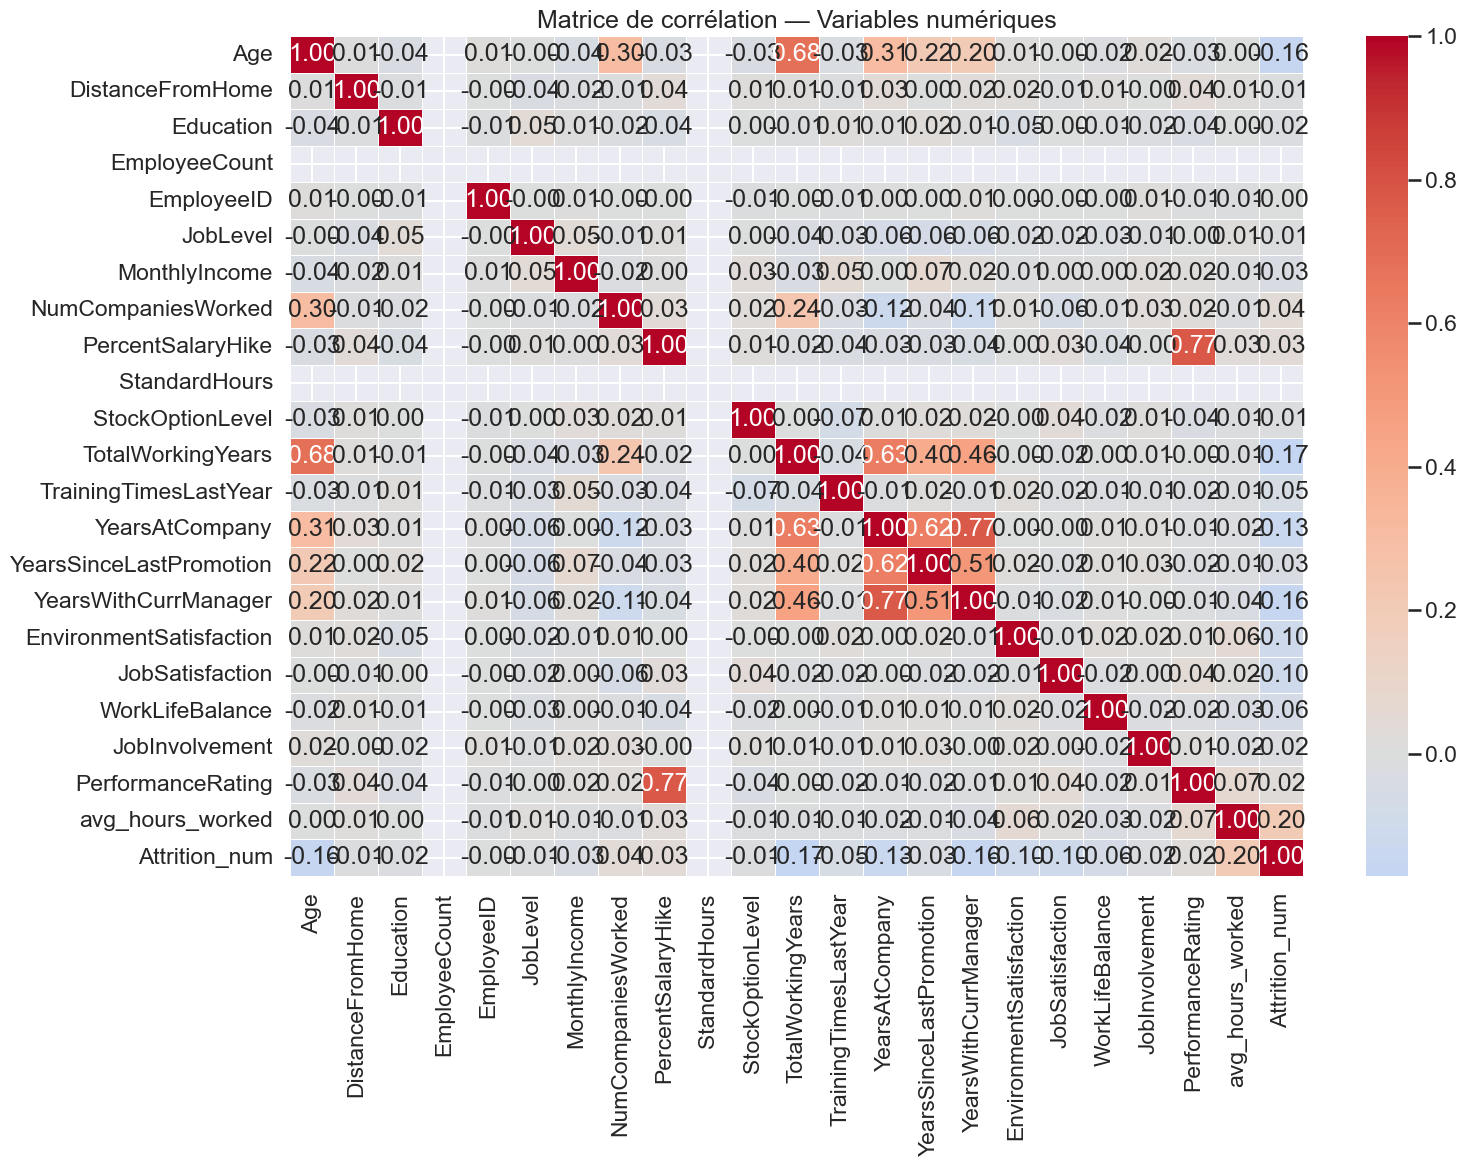

Corrélations avec Attrition (triées) :
avg_hours_worked           0.20
TotalWorkingYears         -0.17
Age                       -0.16
YearsWithCurrManager      -0.16
YearsAtCompany            -0.13
JobSatisfaction           -0.10
EnvironmentSatisfaction   -0.10
WorkLifeBalance           -0.06
TrainingTimesLastYear     -0.05
NumCompaniesWorked         0.04
YearsSinceLastPromotion   -0.03
PercentSalaryHike          0.03
MonthlyIncome             -0.03
PerformanceRating          0.02
JobInvolvement            -0.02
Education                 -0.02
JobLevel                  -0.01
DistanceFromHome          -0.01
StockOptionLevel          -0.01
EmployeeID                -0.00
EmployeeCount               NaN
StandardHours               NaN
Name: Attrition_num, dtype: float64


In [ ]:
# Encode Attrition as binary for correlation computation
corr_data = employee_data.copy()
corr_data['Attrition_num'] = corr_data['Attrition'].map({'Yes': 1, 'No': 0})

# Select numerical columns + encoded Attrition
corr_cols = list(numerical_columns) + ['avg_hours_worked', 'Attrition_num']
corr_cols = [c for c in corr_cols if c in corr_data.columns]
corr_matrix = corr_data[corr_cols].corr()

# Plot heatmap with more spacing
fig, ax = plt.subplots(figsize=(24, 20))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=1.5,
    cbar_kws={'shrink': 0.8},
    ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Matrice de corrélation — Variables numériques', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Display top correlations with Attrition
print('Corrélations avec Attrition (triées) :')
print(corr_matrix['Attrition_num'].drop('Attrition_num').sort_values(key=abs, ascending=False))